In [1]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
def preprocess_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # Rename channels
    raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-CPz', ''))
    
    # Set EOG
    if 'EOG' in raw.ch_names:
        raw.set_channel_types({'EOG': 'eog'})
    
    # Montage
    raw.set_montage('standard_1020', on_missing='ignore')
    
    # Filtering
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    
    # Reference
    raw.set_eeg_reference('average')
    
    return raw

In [3]:
def apply_ica(raw):
    ica = mne.preprocessing.ICA(n_components=15, random_state=42)
    ica.fit(raw)
    
    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices
    
    return ica.apply(raw.copy())

In [4]:
def get_epochs(raw):
    events, event_id = mne.events_from_annotations(raw)
    
    print("Event IDs:", event_id)  # DEBUG
    
    # Use actual names from your dataset
    event_id_clean = {
        'Condition target  EpochE': event_id.get('Condition target  EpochE', 6),
        'Condition non target  EpochE': event_id.get('Condition non target  EpochE', 5)
    }
    
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id_clean,
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True,
        event_repeated='merge'
    )
    
    return epochs

In [5]:
def extract_features(epochs):
    data = epochs.get_data()
    sfreq = epochs.info['sfreq']
    
    features = []
    
    for trial in data:
        signal = trial.mean(axis=0)
        
        amp = np.max(signal)
        latency = np.argmax(signal) / sfreq
        mean = np.mean(signal)
        std = np.std(signal)
        
        psd, _ = mne.time_frequency.psd_array_welch(
            signal, sfreq=sfreq, fmin=0.5, fmax=30
        )
        psd_mean = np.mean(psd)
        
        features.append([amp, latency, mean, std, psd_mean])
    
    return np.array(features)

In [6]:
def generate_labels(X):
    threshold_amp = np.mean(X[:,0])
    threshold_latency = np.mean(X[:,1])
    
    y = []
    
    for amp, lat in X[:, :2]:
        if amp < threshold_amp or lat > threshold_latency:
            y.append(1)
        else:
            y.append(0)
    
    return np.array(y)

In [7]:
def process_folder(folder_path):
    X_all = []
    
    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            path = os.path.join(folder_path, file)
            print("Processing:", file)
            
            raw = preprocess_eeg(path)
            raw = apply_ica(raw)
            epochs = get_epochs(raw)
            
            X = extract_features(epochs['Condition target  EpochE'])
            X_all.extend(X)
    
    X_all = np.array(X_all)
    y_all = generate_labels(X_all)
    
    return X_all, y_all   # 🔥 IMPORTANT

In [8]:
def train_models(X, y):
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.metrics import accuracy_score, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    models = {
        "SVM": SVC(),
        "Random Forest": RandomForestClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier()
    }
    
    results = {}
    
    for name, model in models.items():
        
        if name in ["SVM", "Logistic Regression", "KNN"]:
            model.fit(X_train_s, y_train)
            y_pred = model.predict(X_test_s)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        
        print(f"\n{name} Accuracy:", acc)
        
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
        plt.title(name)
        plt.show()
    
    return models, results

In [9]:
def predict_file(model, file_path):
    raw = preprocess_eeg(file_path)
    raw = apply_ica(raw)
    epochs = get_epochs(raw)
    
    # 🔥 Auto-detect correct event name
    print("Available events:", epochs.event_id)
    
    target_key = None
    for key in epochs.event_id.keys():
        if "target" in key.lower():
            target_key = key
            break
    
    if target_key is None:
        print("❌ No target event found!")
        return
    
    X = extract_features(epochs[target_key])
    
    pred = model.predict(X)
    final = int(np.round(np.mean(pred)))
    
    if final == 1:
        print("🧠 Result: TBI Detected")
    else:
        print("🧠 Result: Healthy")

Processing: a1_auditory_2026-04-07_10-32-53_Segment_0.edf
Extracting EDF parameters from E:\aditi_eeg\auditory_eeg\a1_auditory_2026-04-07_10-32-53_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 347135  =      0.000 ...   338.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 6.8s.
Using EOG channel: EOG


...

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 8.7s.
Using EOG channel: EOG


C:\Users\HP\AppData\Local\Temp\ipykernel_86952\1483069325.py:3: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (33) and smallest (3.1e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 7
  ica.fit(raw)


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 s

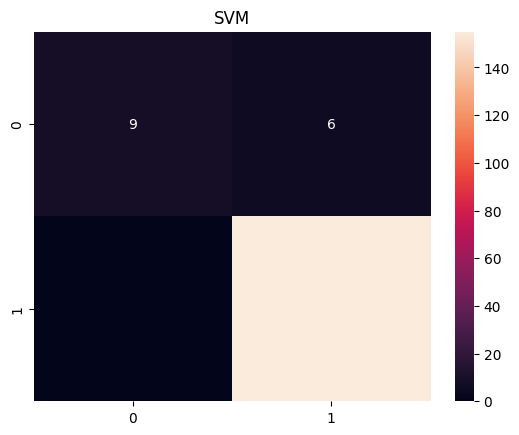


Random Forest Accuracy: 0.9764705882352941


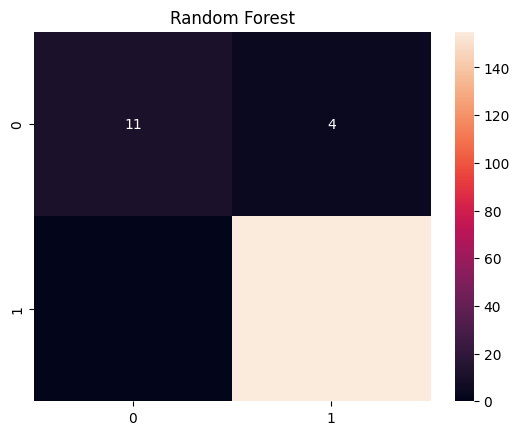


Logistic Regression Accuracy: 0.9117647058823529


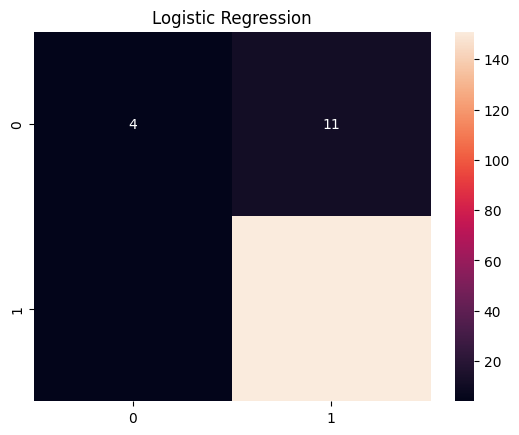


KNN Accuracy: 0.9352941176470588


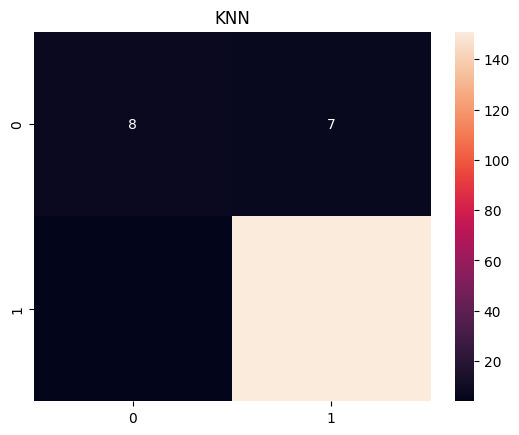


✅ Best Model Selected: Random Forest


In [10]:
folder = r"E:\aditi_eeg\auditory_eeg"

# 🔷 Process all files
X, y = process_folder(folder)

print("Dataset shape:", X.shape)
print("Label distribution:", np.bincount(y))

# ❗ Check if both classes exist
if len(np.unique(y)) < 2:
    print("⚠️ Only one class detected. Model cannot be trained properly.")
else:
    # 🔷 Train models
    models, results = train_models(X, y)

    # 🔥 Auto-select best model
    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]

    print("\n✅ Best Model Selected:", best_model_name)

    # 🔷 CLI Prediction Loop (better than one-time input)
    while True:
        file_input = input("\nEnter EDF file path (or type 'exit'): ")
        
        if file_input.lower() == 'exit':
            break
        
        try:
            predict_file(best_model, file_input)
        except Exception as e:
            print("❌ Error processing file:", e)